# Notebook 2: Identifiability, Cutpoints, and Signal Detection Theory

**Time:** 60--90 minutes

**Purpose:** Understand why ordinal models require anchoring, how cutpoint structure relates to expert heterogeneity, and how the latent-threshold model relates to signal detection theory. Write the DCM leaf-node likelihood.

**Prerequisites:** Notebook 1 (latent-threshold models, `ordinal_probs` function, two-group model).

**DCM context:** This notebook builds toward the ordinal probit observation model that will replace the current mean-then-Bernoulli approach.

In [25]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import expit, logit
from scipy.stats import norm
from scipy.special import logsumexp

rng = np.random.default_rng(42)


def ordinal_probs(
    cutpoints: np.ndarray, eta: float = 0.0, cdf: str = "logistic"
) -> np.ndarray:
    """Compute ordinal probabilities from cutpoints and linear predictor."""
    c_aug = np.concatenate([[-np.inf], cutpoints, [np.inf]])
    if cdf == "logistic":
        return np.diff(expit(c_aug - eta))
    elif cdf == "probit":
        return np.diff(norm.cdf(c_aug - eta))
    raise ValueError(f"Unknown cdf: {cdf}")

### Learning objectives

1. Diagnose and fix location non-identifiability between cutpoints and the linear predictor.
2. Diagnose and fix tail degeneracies from empty ordinal categories.
3. Distinguish shared-cutpoint and heterogeneous-cutpoint models.
4. Map ordinal regression terminology to signal detection theory.
5. Write the DCM leaf-node marginal likelihood.

---

## Part A: Identifiability and degeneracies

Notebook 1 ended by noting that cutpoints and $\eta$ are only identified up to a common translation. Now we make this concrete and see what goes wrong when the model is not properly anchored.

## 1. Location non-identifiability

Recall:

$$p_k = F(c_k - \eta) - F(c_{k-1} - \eta).$$

The transformation $c_k \to c_k + \delta$, $\eta \to \eta + \delta$ leaves **all** ordinal probabilities unchanged for any $\delta$. The likelihood has a **ridge** along this direction -- a one-dimensional manifold of equally good parameter values. The posterior for $(c, \eta)$ is only identified up to a common translation.

In [26]:
# Synthetic data for Part A
true_cutpoints: np.ndarray = np.array([-1.5, -0.5, 0.5, 1.5])
K: int = len(true_cutpoints) + 1
N: int = 300

true_probs: np.ndarray = ordinal_probs(true_cutpoints, eta=0.0)
y_obs: np.ndarray = rng.choice(K, size=N, p=true_probs)
print("Empirical frequencies:", np.round(np.bincount(y_obs, minlength=K) / N, 3))

Empirical frequencies: [0.223 0.173 0.227 0.21  0.167]


### 1.1 The broken model: free cutpoints AND free intercept

We intentionally add a free intercept $\mu$ alongside free cutpoints to create the non-identifiability. The model has $K$ free parameters for only $K - 1$ identifiable quantities.

In [27]:
with pm.Model() as broken_model:
    mu = pm.Normal("mu", mu=0.0, sigma=5.0)
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1, 1, K - 1),
    )
    y_lik = pm.OrderedLogistic("y", eta=mu, cutpoints=cp, observed=y_obs)

with broken_model:
    idata_broken = pm.sample(
        draws=500, tune=1000, chains=4, random_seed=42, target_accept=0.95
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 3 seconds.


In [28]:
# Expect: terrible R-hat, very low ESS
az.summary(idata_broken, var_names=["mu", "cutpoints"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,-0.063,1.001,-1.879,1.826,0.032,0.028,982.0,949.0,1.0
cutpoints[0],-1.322,1.004,-3.130,0.567,0.032,0.029,1005.0,1002.0,1.0
cutpoints[1],-0.482,1.000,-2.372,1.320,0.032,0.028,999.0,895.0,1.0
cutpoints[2],0.443,0.998,-1.350,2.354,0.032,0.027,961.0,1035.0,1.0
cutpoints[3],1.559,1.000,-0.260,3.433,0.032,0.027,983.0,1155.0,1.0


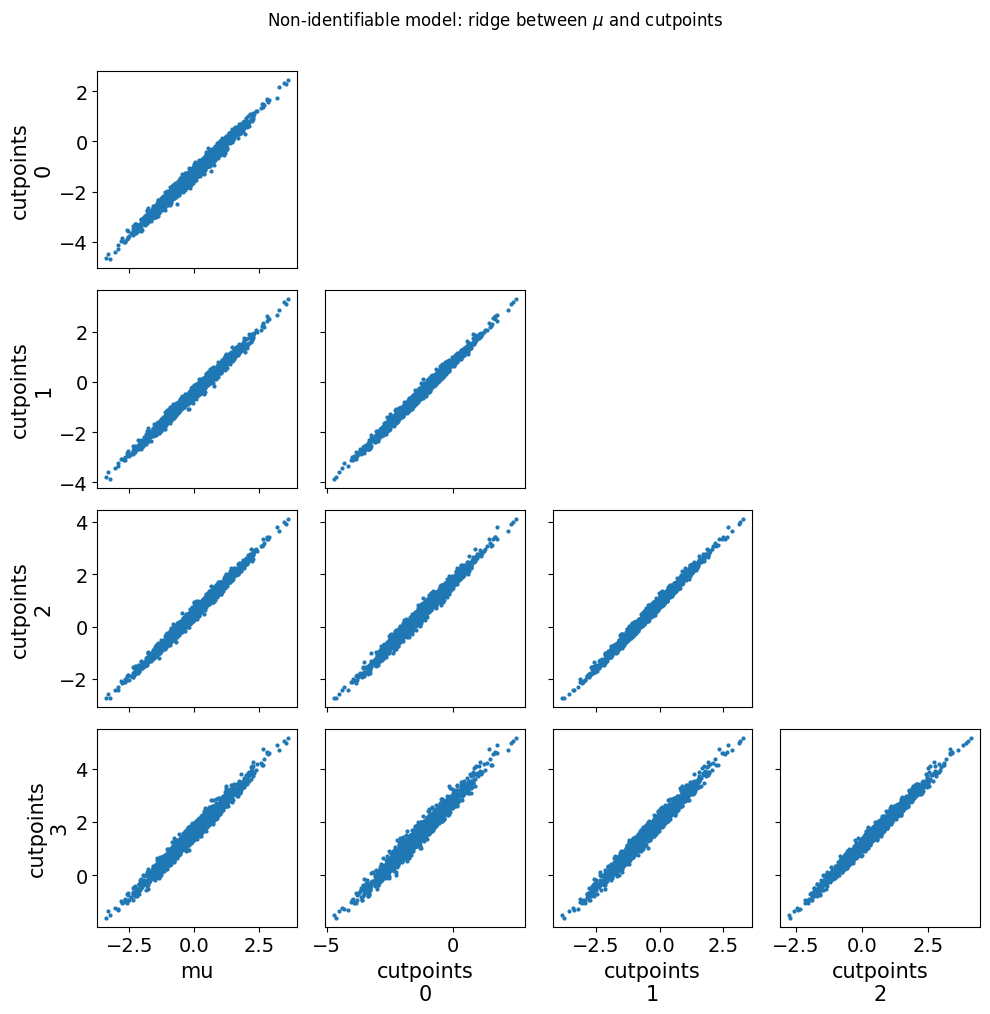

In [29]:
# Pair plot: the ridge between mu and cutpoints
az.plot_pair(
    idata_broken, var_names=["mu", "cutpoints"], divergences=True, figsize=(10, 10)
)
plt.suptitle("Non-identifiable model: ridge between $\\mu$ and cutpoints", y=1.01)
plt.tight_layout()
plt.show()

The pair plots should show **diagonal ridges** -- $\mu$ and each cutpoint drift together. The sampler can slide along this ridge without changing the likelihood. The marginal posteriors are wide and poorly mixing, but the **differences** $c_k - \mu$ are well-identified.

This is a **global** non-identifiability, not a local one: the posterior is genuinely ridge-shaped.

In [30]:
# Verify: the differences c_k - mu ARE well-identified
mu_draws: np.ndarray = idata_broken.posterior["mu"].values.flatten()
cp_draws: np.ndarray = idata_broken.posterior[
    "cutpoints"
].values  # (chains, draws, K-1)
cp_flat: np.ndarray = cp_draws.reshape(-1, K - 1)

diffs: np.ndarray = cp_flat - mu_draws[:, None]
print("Posterior mean of (c_k - mu):", np.round(diffs.mean(axis=0), 3))
print("Posterior sd of (c_k - mu):  ", np.round(diffs.std(axis=0), 3))
print(f"\nTrue cutpoints (with eta=0): {true_cutpoints}")

Posterior mean of (c_k - mu): [-1.259 -0.419  0.506  1.622]
Posterior sd of (c_k - mu):   [0.138 0.118 0.119 0.154]

True cutpoints (with eta=0): [-1.5 -0.5  0.5  1.5]


### 1.2 Fixing the non-identifiability

Three strategies:

**(a) Fix the intercept to 0.** Drop $\mu$ entirely -- use `eta=0` (or `eta=beta * x` for regression, with no free intercept). This is the standard convention and what `pm.OrderedLogistic` expects.

**(b) Anchor one cutpoint.** Fix $c_1 = 0$ and estimate only $c_2, \ldots, c_{K-1}$ and a free $\mu$.

**(c) Use a strong prior.** A tight prior on $\mu$ (or on the cutpoint mean) can weakly identify the model, but this is less clean.

Strategy (a) is the most common. Let's verify it resolves the problem.

In [31]:
# Strategy (a): fix intercept to 0
with pm.Model() as fixed_model:
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1, 1, K - 1),
    )
    y_lik = pm.OrderedLogistic("y", eta=0.0, cutpoints=cp, observed=y_obs)

with fixed_model:
    idata_fixed = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

az.summary(idata_fixed, var_names=["cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in add
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-1.259,0.139,-1.527,-1.006,0.003,0.002,3042.0,2667.0,1.0
cutpoints[1],-0.425,0.118,-0.631,-0.184,0.002,0.002,4503.0,3469.0,1.0
cutpoints[2],0.505,0.119,0.289,0.724,0.002,0.002,5784.0,3559.0,1.0
cutpoints[3],1.621,0.154,1.338,1.911,0.002,0.002,5775.0,3529.0,1.0


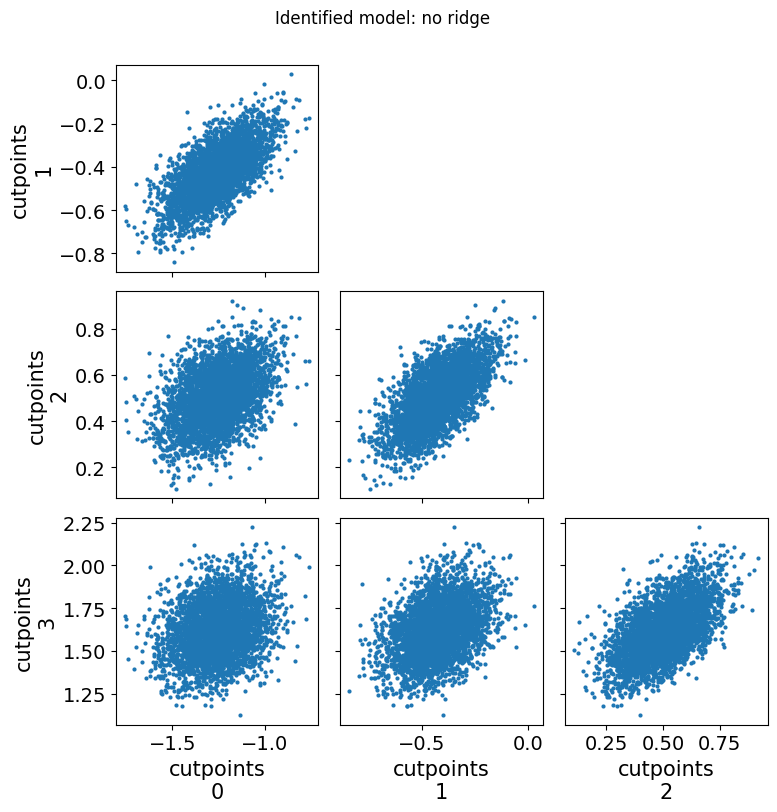

In [32]:
# Clean pair plot -- no ridge
az.plot_pair(idata_fixed, var_names=["cutpoints"], figsize=(8, 8))
plt.suptitle("Identified model: no ridge", y=1.01)
plt.tight_layout()
plt.show()

## 2. Tail degeneracies

Even with proper anchoring, another pathology can arise: when an ordinal category has **zero (or very few) observations**, the bounding cutpoint is unconstrained by data and drifts toward $\pm\infty$.

The sensitivity $\partial p_k / \partial c_k = f(c_k)$ (the latent PDF evaluated at the cutpoint). In the tails, $f(c_k) \to 0$, so the likelihood becomes insensitive to the cutpoint's exact location. Without a compensating prior, the posterior spreads to infinity.

In [33]:
# Data with an empty first category
# Use cutpoints that put very little mass on category 0, then remove those obs
c_tail: np.ndarray = np.array([-3.5, -0.5, 0.5, 1.5])
p_tail: np.ndarray = ordinal_probs(c_tail, eta=0.0)
print("True probs (note tiny p_0):", np.round(p_tail, 4))

y_tail_raw: np.ndarray = rng.choice(K, size=400, p=p_tail)
# Remove all category-0 observations to simulate empty category
y_tail: np.ndarray = y_tail_raw[y_tail_raw > 0]
print(f"\nObservations: {len(y_tail)} (removed {(y_tail_raw == 0).sum()} cat-0 obs)")
print("Observed counts:", np.bincount(y_tail, minlength=K))

True probs (note tiny p_0): [0.0293 0.3482 0.2449 0.1951 0.1824]

Observations: 391 (removed 9 cat-0 obs)
Observed counts: [  0 133  97  87  74]


In [34]:
# Fit with a weak prior -- expect c_1 to drift
with pm.Model() as tail_model_weak:
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=10.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-2, 2, K - 1),
    )
    y_lik = pm.OrderedLogistic("y", eta=0.0, cutpoints=cp, observed=y_tail)

with tail_model_weak:
    idata_tail = pm.sample(
        draws=500, tune=1000, chains=2, random_seed=42, target_accept=0.95
    )

az.summary(idata_tail, var_names=["cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-16.780,11.141,-43.841,-6.697,4.977,4.548,10.0,11.0,1.17
cutpoints[1],-0.678,0.109,-0.873,-0.453,0.012,0.004,72.0,472.0,1.03
cutpoints[2],0.364,0.104,0.166,0.556,0.004,0.003,770.0,685.0,1.00
cutpoints[3],1.496,0.138,1.243,1.741,0.030,0.007,23.0,114.0,1.06


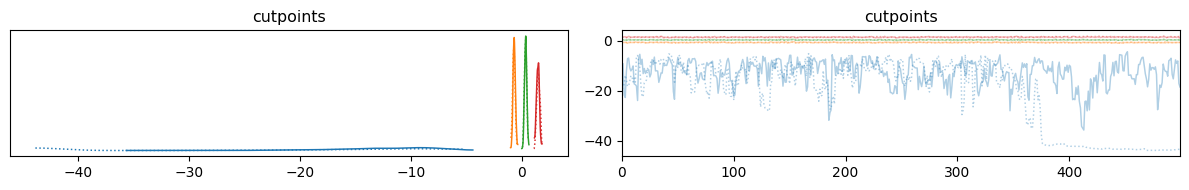

In [35]:
# Trace plot: watch c_1 drift leftward
az.plot_trace(idata_tail, var_names=["cutpoints"])
plt.tight_layout()
plt.show()

### 2.1 Fix with an informative prior

A tighter prior on cutpoints prevents the drift. This is the simplest fix and often sufficient in practice.

In [36]:
# Tighter prior: sigma=2 instead of sigma=10
with pm.Model() as tail_model_tight:
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-2, 2, K - 1),
    )
    y_lik = pm.OrderedLogistic("y", eta=0.0, cutpoints=cp, observed=y_tail)

with tail_model_tight:
    idata_tail_tight = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

az.summary(idata_tail_tight, var_names=["cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in add
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in add
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-5.926,0.864,-7.491,-4.405,0.024,0.022,1523.0,1403.0,1.0
cutpoints[1],-0.655,0.108,-0.859,-0.455,0.002,0.002,2961.0,2969.0,1.0
cutpoints[2],0.363,0.103,0.172,0.555,0.002,0.001,3208.0,2951.0,1.0
cutpoints[3],1.464,0.128,1.215,1.695,0.002,0.002,3354.0,3392.0,1.0


### 2.2 The induced Dirichlet prior (brief)

A more principled approach: place a **Dirichlet prior on the ordinal probabilities** $(p_1, \ldots, p_K)$ and push it through the inverse CDF to induce a prior on cutpoints. This naturally prevents tail collapse because the Dirichlet assigns low density to extreme simplex configurations.

Implementation: compute ordinal probs from cutpoints, add the Dirichlet log-density as a `pm.Potential`. The Jacobian of the transformation is $\prod_{k=1}^{K-1} f(c_k)$ (the latent PDF at each cutpoint).

This is the "induced Dirichlet" model from Betancourt. We show it works; the full derivation is in the PDF if you want the details.

In [37]:
# Induced Dirichlet prior on cutpoints
with pm.Model() as tail_model_dirichlet:
    # Free (unconstrained) cutpoints -- the induced Dirichlet acts as the prior
    cp = pm.Flat(
        "cutpoints",
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-2, 2, K - 1),
    )

    # Compute ordinal probabilities from cutpoints (logistic CDF)
    c_aug = pt.concatenate([[-100.0], cp, [100.0]])  # approximate +/- inf
    F_vals = pt.sigmoid(c_aug)
    probs = F_vals[1:] - F_vals[:-1]

    # Induced Dirichlet log-density (uniform Dirichlet: alpha = 1 for all k)
    # log p(probs) under Dirichlet(1,...,1) is just a constant, so the
    # key contribution is the Jacobian: sum of log f(c_k) for each cutpoint
    log_jac = pt.sum(pt.log(pt.sigmoid(cp) * (1 - pt.sigmoid(cp))))
    pm.Potential("induced_dirichlet", log_jac)

    y_lik = pm.OrderedLogistic("y", eta=0.0, cutpoints=cp, observed=y_tail)

with tail_model_dirichlet:
    idata_tail_dir = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

az.summary(idata_tail_dir, var_names=["cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in add
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in add
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-6.554,1.214,-8.839,-4.539,0.043,0.045,1028.0,868.0,1.0
cutpoints[1],-0.659,0.104,-0.861,-0.465,0.002,0.001,2845.0,3216.0,1.0
cutpoints[2],0.357,0.099,0.173,0.539,0.002,0.001,3222.0,3261.0,1.0
cutpoints[3],1.461,0.128,1.222,1.714,0.002,0.002,3136.0,2895.0,1.0


**Part A summary.** Two things to always check in ordinal models:

1. **Location anchoring:** never have both free cutpoints and a free intercept. Fix one.
2. **Tail regularisation:** if some categories may be empty, use an informative prior (or the induced Dirichlet) to prevent cutpoints from drifting to $\pm\infty$.

Diagnostics to watch: R-hat >> 1, very low ESS, diagonal ridges in pair plots, drifting trace plots.

---

## Part B: Shared vs heterogeneous cutpoints

When **multiple experts** rate **multiple items**, we need to model how different sources of variation interact with the cutpoint structure.

## 3. The pairwise comparison framing

Each observed rating is a pair $(e, j)$: expert $e$ rates item $j$. Two sources of variation:

- **Expert austerity** $\alpha_e$: how harsh expert $e$ is (shifts their latent threshold downward, reducing ratings).
- **Item quality** $\gamma_j$: how "good" item $j$ truly is (higher quality shifts ratings upward).

The linear predictor: $\eta_{ej} = \gamma_j - \alpha_e$.

Positive $\gamma_j - \alpha_e$ means the item's quality exceeds the expert's austerity threshold, producing higher ratings.

## 4. Shared cutpoints

All experts use the **same** cutpoints. Heterogeneity comes entirely from different $\alpha_e$ and $\gamma_j$:

$$p_k(e, j) = F(c_k - \gamma_j + \alpha_e) - F(c_{k-1} - \gamma_j + \alpha_e).$$

**Identifiability:** we have the same location non-identifiability as before, plus an additional one between $\alpha_e$ and $\gamma_j$ (adding a constant to all $\alpha_e$ and all $\gamma_j$ is undetectable). Fix by **anchoring one item quality** to zero: $\gamma_1 = 0$.

In [40]:
# Synthetic data: 3 experts, 4 items, shared cutpoints
n_experts: int = 3
n_items: int = 4
n_ratings_per_pair: int = 25

true_alpha: np.ndarray = np.array([0.0, 0.8, -0.5])  # expert austerity
true_gamma: np.ndarray = np.array([0.0, 1.2, -0.7, 0.5])  # item quality (gamma_0 = 0)
true_cp: np.ndarray = np.array([-1.5, -0.5, 0.5, 1.5])

# Generate all (expert, item) pairs
expert_idx_list: list[int] = []
item_idx_list: list[int] = []
y_list: list[int] = []

for e in range(n_experts):
    for j in range(n_items):
        eta_ej: float = true_gamma[j] - true_alpha[e]
        p_ej: np.ndarray = ordinal_probs(true_cp, eta_ej)
        ratings = rng.choice(K, size=n_ratings_per_pair, p=p_ej)
        expert_idx_list.extend([e] * n_ratings_per_pair)
        item_idx_list.extend([j] * n_ratings_per_pair)
        y_list.extend(ratings.tolist())

expert_idx: np.ndarray = np.array(expert_idx_list)
item_idx: np.ndarray = np.array(item_idx_list)
y_shared: np.ndarray = np.array(y_list)

print(f"Total observations: {len(y_shared)}")
print(f"Experts: {n_experts}, Items: {n_items}")

Total observations: 300
Experts: 3, Items: 4


In [42]:
# PyMC shared-cutpoint model
# Anchor: gamma_0 = 0 (already built into true_gamma)
# alpha_0 is free -- no need to anchor both, because gamma_0 = 0 absorbs the shift

with pm.Model() as shared_cp_model:
    # Expert austerity (all free -- gamma_0=0 anchors the location)
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0, shape=n_experts)

    # Item quality: gamma_0 = 0 (anchor), rest are free
    gamma_free = pm.Normal("gamma_free", mu=0.0, sigma=2.0, shape=n_items - 1)
    gamma = pt.concatenate([pt.zeros(1), gamma_free])

    # Shared ordered cutpoints
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1.5, 1.5, K - 1),
    )

    # Linear predictor for each observation
    eta = gamma[item_idx] - alpha[expert_idx]

    y_lik = pm.OrderedLogistic("y", eta=eta, cutpoints=cp, observed=y_shared)

with shared_cp_model:
    idata_shared = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, gamma_free, cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


In [43]:
# Posterior comparison to true values
print("=== Expert austerity (alpha) ===")
print(f"  True:      {true_alpha}")
alpha_post = idata_shared.posterior["alpha"].mean(dim=("chain", "draw")).values
print(f"  Posterior:  {np.round(alpha_post, 3)}")

print("\n=== Item quality (gamma) ===")
gamma_free_post = (
    idata_shared.posterior["gamma_free"].mean(dim=("chain", "draw")).values
)
gamma_post = np.concatenate([[0.0], gamma_free_post])
print(f"  True:      {true_gamma}")
print(f"  Posterior:  {np.round(gamma_post, 3)}")

print("\n=== Cutpoints ===")
cp_post = idata_shared.posterior["cutpoints"].mean(dim=("chain", "draw")).values
print(f"  True:      {true_cp}")
print(f"  Posterior:  {np.round(cp_post, 3)}")

az.summary(idata_shared, var_names=["alpha", "gamma_free", "cutpoints"])

=== Expert austerity (alpha) ===
  True:      [ 0.   0.8 -0.5]
  Posterior:  [ 0.196  0.531 -0.644]

=== Item quality (gamma) ===
  True:      [ 0.   1.2 -0.7  0.5]
  Posterior:  [ 0.     0.788 -0.893  0.394]

=== Cutpoints ===
  True:      [-1.5 -0.5  0.5  1.5]
  Posterior:  [-1.374 -0.625  0.515  1.514]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],0.196,0.748,-1.174,1.610,0.019,0.013,1528.0,1989.0,1.0
alpha[1],0.531,0.747,-0.900,1.905,0.019,0.013,1587.0,1900.0,1.0
alpha[2],-0.644,0.751,-2.071,0.739,0.019,0.013,1598.0,1969.0,1.0
gamma_free[0],0.788,0.293,0.213,1.322,0.006,0.005,2799.0,2651.0,1.0
gamma_free[1],-0.893,0.298,-1.441,-0.321,0.006,0.004,2772.0,2656.0,1.0
gamma_free[2],0.394,0.286,-0.160,0.928,0.005,0.004,2784.0,2820.0,1.0
cutpoints[0],-1.374,0.738,-2.697,0.062,0.018,0.013,1623.0,2001.0,1.0
cutpoints[1],-0.625,0.737,-1.920,0.818,0.019,0.013,1571.0,2133.0,1.0
cutpoints[2],0.515,0.737,-0.837,1.936,0.018,0.013,1593.0,2148.0,1.0
cutpoints[3],1.514,0.742,0.148,2.912,0.018,0.013,1609.0,2176.0,1.0


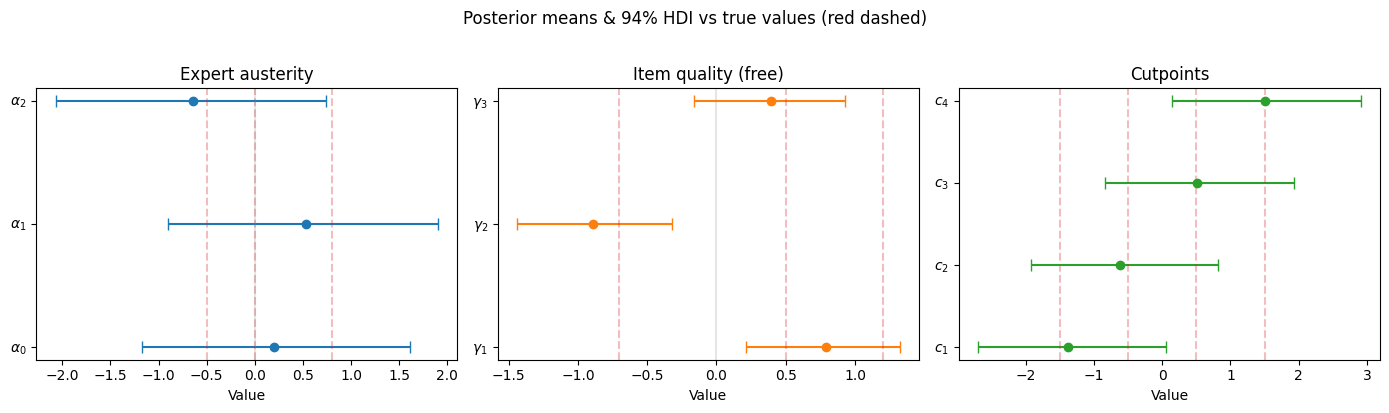

In [44]:
# Forest plot: compare posteriors to true values
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Alpha
ax = axes[0]
alpha_hdi = az.hdi(idata_shared, var_names=["alpha"])["alpha"].values
for i in range(n_experts):
    ax.errorbar(
        alpha_post[i],
        i,
        xerr=[[alpha_post[i] - alpha_hdi[i, 0]], [alpha_hdi[i, 1] - alpha_post[i]]],
        fmt="o",
        color="C0",
        capsize=4,
    )
    ax.axvline(true_alpha[i], color="C3", alpha=0.3, ls="--")
ax.set_yticks(range(n_experts), [f"$\\alpha_{{{i}}}$" for i in range(n_experts)])
ax.set_title("Expert austerity")
ax.axvline(0, color="grey", alpha=0.2)

# Gamma
ax = axes[1]
gamma_hdi_free = az.hdi(idata_shared, var_names=["gamma_free"])["gamma_free"].values
for i in range(n_items - 1):
    ax.errorbar(
        gamma_free_post[i],
        i,
        xerr=[
            [gamma_free_post[i] - gamma_hdi_free[i, 0]],
            [gamma_hdi_free[i, 1] - gamma_free_post[i]],
        ],
        fmt="o",
        color="C1",
        capsize=4,
    )
    ax.axvline(true_gamma[i + 1], color="C3", alpha=0.3, ls="--")
ax.set_yticks(
    range(n_items - 1), [f"$\\gamma_{{{i + 1}}}$" for i in range(n_items - 1)]
)
ax.set_title("Item quality (free)")
ax.axvline(0, color="grey", alpha=0.2)

# Cutpoints
ax = axes[2]
cp_hdi = az.hdi(idata_shared, var_names=["cutpoints"])["cutpoints"].values
for i in range(K - 1):
    ax.errorbar(
        cp_post[i],
        i,
        xerr=[[cp_post[i] - cp_hdi[i, 0]], [cp_hdi[i, 1] - cp_post[i]]],
        fmt="o",
        color="C2",
        capsize=4,
    )
    ax.axvline(true_cp[i], color="C3", alpha=0.3, ls="--")
ax.set_yticks(range(K - 1), [f"$c_{{{i + 1}}}$" for i in range(K - 1)])
ax.set_title("Cutpoints")

for ax in axes:
    ax.set_xlabel("Value")
plt.suptitle("Posterior means & 94% HDI vs true values (red dashed)", y=1.02)
plt.tight_layout()
plt.show()

### 4.1 Why shared cutpoints?

When cutpoints are shared, all expert heterogeneity is captured by the $\alpha_e$ shifts. This is a strong assumption: it says experts differ in **how harshly they rate** but agree on **how to partition the latent scale into categories**.

This is reasonable when experts share a common rubric or training. The DCM assumes shared cutpoints across experts for exactly this reason -- experts observe the same latent state and use the same rating scale.

**Heterogeneous cutpoints** (each expert gets their own $c_k^{(e)}$) are more flexible but require more data per expert to estimate. We will not fit this model here, but the extension is straightforward: replace the single `cutpoints` vector with a matrix indexed by expert.

---

## Part C: Signal detection theory as ordinal regression

Signal detection theory (SDT) and ordinal regression share the same latent-threshold construction. The terminology differs, but the maths is identical.

### 5. The SDT setup

In a **rating** SDT experiment:

- The observer sees a stimulus drawn from either a **noise** distribution ($z = 0$) or a **signal+noise** distribution ($z = 1$).
- Both distributions are Gaussian with unit variance. Signal+noise has mean $d'$ (sensitivity); noise has mean $0$.
- The observer has $K - 1$ **criteria** (cutpoints) $c_1 < c_2 < \cdots < c_{K-1}$ that partition the latent axis into $K$ response categories.

The probability of response $k$ given stimulus class $z$:

$$P(R = k \mid z) = \Phi(c_k - d' \cdot z) - \Phi(c_{k-1} - d' \cdot z)$$

where $\Phi$ is the standard normal CDF. This is exactly the ordered probit model with $\eta = d' \cdot z$.

### 5.1 Terminology mapping

| SDT | Ordinal regression | DCM |
|---|---|---|
| Sensitivity $d'$ | Regression coefficient $\beta$ | Discrimination $a$ (or $\gamma_j - \alpha_e$) |
| Criteria $c_1, \ldots, c_{K-1}$ | Cutpoints $c_1, \ldots, c_{K-1}$ | Shared cutpoints $\kappa$ |
| Noise distribution ($z=0$) | Baseline group | Latent state $z=0$ |
| Signal+noise ($z=1$) | Treatment group | Latent state $z=1$ |
| Normal CDF $\Phi$ | Probit link | Probit link |
| Logistic CDF | Logit link | Logit link |
| Bias $c$ (single criterion) | Intercept (absorbed into cutpoints) | Expert austerity $\alpha_e$ |

The key insight: **SDT rating models are a special case of ordinal regression** where the covariate is the binary stimulus class (DeCarlo, 1998).

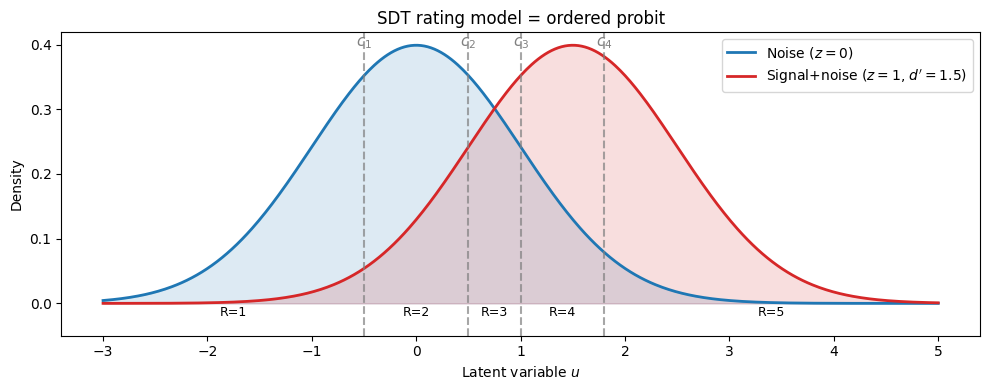

In [45]:
# Visualisation: noise vs signal+noise densities with criteria
d_prime: float = 1.5
criteria: np.ndarray = np.array([-0.5, 0.5, 1.0, 1.8])

x = np.linspace(-3, 5, 500)
fig, ax = plt.subplots(figsize=(10, 4))

# Noise and signal+noise densities
ax.plot(x, norm.pdf(x, 0), "C0", lw=2, label="Noise ($z=0$)")
ax.fill_between(x, norm.pdf(x, 0), alpha=0.15, color="C0")
ax.plot(
    x, norm.pdf(x, d_prime), "C3", lw=2, label=f"Signal+noise ($z=1$, $d'={d_prime}$)"
)
ax.fill_between(x, norm.pdf(x, d_prime), alpha=0.15, color="C3")

# Criteria as vertical lines
for i, c in enumerate(criteria):
    ax.axvline(c, color="grey", ls="--", alpha=0.7)
    ax.text(
        c,
        ax.get_ylim()[1] * 0.95,
        f"$c_{{{i + 1}}}$",
        ha="center",
        fontsize=11,
        color="grey",
    )

# Label response categories
cat_bounds = [-3.0] + criteria.tolist() + [5.0]
for i in range(len(criteria) + 1):
    mid = (cat_bounds[i] + cat_bounds[i + 1]) / 2
    ax.text(mid, -0.02, f"R={i + 1}", ha="center", fontsize=9, color="black")

ax.set_xlabel("Latent variable $u$")
ax.set_ylabel("Density")
ax.set_title("SDT rating model = ordered probit")
ax.legend(loc="upper right")
ax.set_ylim(-0.05, None)
plt.tight_layout()
plt.show()

In [46]:
# Numerical verification: SDT probabilities = ordinal_probs with probit link
print("Response probabilities under noise (z=0):")
p_noise = ordinal_probs(criteria, eta=0.0, cdf="probit")
print(f"  ordinal_probs: {np.round(p_noise, 4)}")

print("\nResponse probabilities under signal (z=1):")
p_signal = ordinal_probs(criteria, eta=d_prime, cdf="probit")
print(f"  ordinal_probs: {np.round(p_signal, 4)}")

# Manual SDT calculation for comparison
c_aug = np.concatenate([[-np.inf], criteria, [np.inf]])
p_signal_manual = np.diff(norm.cdf(c_aug - d_prime))
print(f"  manual SDT:    {np.round(p_signal_manual, 4)}")
print(f"\n  Match: {np.allclose(p_signal, p_signal_manual)}")

Response probabilities under noise (z=0):
  ordinal_probs: [0.3085 0.3829 0.1499 0.1227 0.0359]

Response probabilities under signal (z=1):
  ordinal_probs: [0.0228 0.1359 0.1499 0.3094 0.3821]
  manual SDT:    [0.0228 0.1359 0.1499 0.3094 0.3821]

  Match: True


---

## Part D: DCM leaf-node observation model

We now connect everything to the DCM. At each **leaf node** (skill $s$, item $j$), a binary latent state $z_{sj} \in \{0, 1\}$ represents whether the student has mastered the skill. Multiple experts $e = 1, \ldots, E$ independently rate the student's performance.

### 6. The model

The latent continuous perception for expert $e$ on item $j$ with skill $s$:

$$u_{esj} \mid z_{sj} \sim \mathcal{N}(b_e + a \cdot z_{sj}, \; 1)$$

where:
- $b_e$ is the expert-specific bias (austerity, maps to $-\alpha_e$ from Part B),
- $a > 0$ is the discrimination (maps to $d'$ from SDT),
- the variance is fixed to 1 for identifiability (same convention as SDT).

The observed ordinal rating $r_{esj} \in \{1, \ldots, K\}$ is determined by shared cutpoints $\kappa$:

$$P(r_{esj} = k \mid z_{sj}) = \Phi(\kappa_k - b_e - a \cdot z_{sj}) - \Phi(\kappa_{k-1} - b_e - a \cdot z_{sj})$$

This is the ordered probit model with $\eta_{esj} = b_e + a \cdot z_{sj}$.

### 6.1 Marginal leaf-node likelihood

The latent state $z_{sj}$ is not observed. Given a prior $q = P(z_{sj} = 1)$ (from the tree above), we marginalise:

$$P(\mathbf{r}_{sj} \mid q, \theta) = \sum_{z \in \{0,1\}} P(z \mid q) \prod_{e=1}^{E} P(r_{esj} \mid z, \theta)$$

where $\mathbf{r}_{sj} = (r_{1sj}, \ldots, r_{Esj})$ is the vector of all expert ratings and $\theta = (a, \{b_e\}, \kappa)$.

Expanding:

$$P(\mathbf{r}_{sj} \mid q, \theta) = (1 - q) \prod_{e} P(r_{esj} \mid z=0, \theta) \;+\; q \prod_{e} P(r_{esj} \mid z=1, \theta)$$

This is a **two-component mixture** with known mixing weight $q$. Each component is a product of independent ordered probit likelihoods across experts.

In [47]:
def leaf_log_lik(
    ratings: np.ndarray,
    q: float,
    a: float,
    b: np.ndarray,
    kappa: np.ndarray,
) -> float:
    """Log marginal likelihood for one leaf node.

    Parameters
    ----------
    ratings : array of shape (E,), observed ordinal ratings (0-indexed).
    q : prior probability of z=1 (mastery).
    a : discrimination (d').
    b : array of shape (E,), expert biases.
    kappa : array of shape (K-1,), shared cutpoints.

    Returns
    -------
    Log P(ratings | q, a, b, kappa).
    """
    E = len(ratings)
    log_components = np.zeros(2)  # z=0, z=1

    for z in range(2):
        log_p_z = np.log(q) if z == 1 else np.log(1 - q)
        log_prod = 0.0
        for e_idx in range(E):
            eta = b[e_idx] + a * z
            probs = ordinal_probs(kappa, eta=eta, cdf="probit")
            log_prod += np.log(probs[ratings[e_idx]] + 1e-30)
        log_components[z] = log_p_z + log_prod

    return logsumexp(log_components)

True z = 1
Expert ratings (0-indexed): [2 5 2]


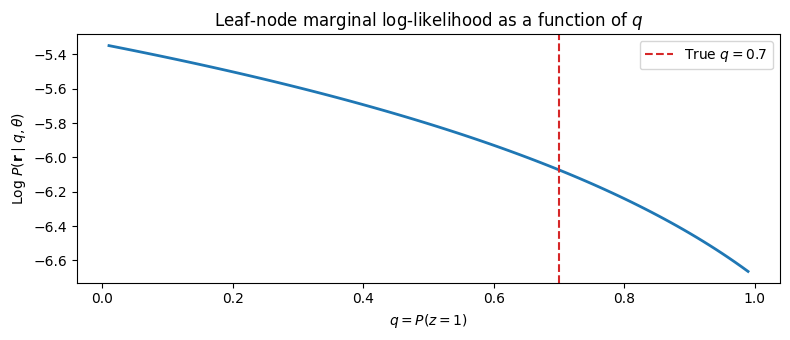

In [21]:
# Numerical example: 3 experts, known parameters
kappa_dcm: np.ndarray = np.array(
    [-1.5, -0.5, 0.0, 0.5, 1.0, 1.5]
)  # 7-point scale, 6 cutpoints
a_dcm: float = 1.2
b_dcm: np.ndarray = np.array([0.0, 0.3, -0.2])  # 3 experts

# Generate one set of ratings under z=1 (mastery)
z_true: int = 1
q_true: float = 0.7

example_ratings: np.ndarray = np.zeros(3, dtype=int)
for e_idx in range(3):
    eta_e = b_dcm[e_idx] + a_dcm * z_true
    probs_e = ordinal_probs(kappa_dcm, eta=eta_e, cdf="probit")
    example_ratings[e_idx] = rng.choice(len(probs_e), p=probs_e)

print(f"True z = {z_true}")
print(f"Expert ratings (0-indexed): {example_ratings}")

# Compute log-likelihood for different q values
q_grid = np.linspace(0.01, 0.99, 100)
ll_grid = np.array(
    [leaf_log_lik(example_ratings, q, a_dcm, b_dcm, kappa_dcm) for q in q_grid]
)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(q_grid, ll_grid, "C0", lw=2)
ax.axvline(q_true, color="C3", ls="--", label=f"True $q = {q_true}$")
ax.set_xlabel("$q = P(z=1)$")
ax.set_ylabel("Log $P(\\mathbf{r} \\mid q, \\theta)$")
ax.set_title("Leaf-node marginal log-likelihood as a function of $q$")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Identifiability check

The DCM leaf-node model inherits the identifiability constraints we studied:

1. **Location:** The variance of the latent normal is fixed to 1 (not estimated). This anchors the scale. Expert biases $b_e$ and cutpoints $\kappa$ are then identified.
2. **Shift:** With $b_1 = 0$ (anchor one expert) or equivalently absorb into cutpoints, the location is pinned.
3. **Tails:** With a 7-point scale and reasonable priors on $\kappa$, tail degeneracy is unlikely but should be monitored.

The discrimination $a$ plays the role of $d'$: it measures how well the rating system separates mastered from unmastered states.

---

## Exercises

### Exercise 1: Alternative anchoring (pen-and-paper)

In the shared-cutpoint model (Part B), we anchored $\gamma_1 = 0$. Suppose instead you anchor the **first cutpoint** $c_1 = 0$ and leave all $\gamma_j$ free (including $\gamma_1$).

**(a)** How many free parameters does this model have? Compare to the $\gamma_1 = 0$ version.

**(b)** Can you still identify all $\alpha_e$ and $\gamma_j$ individually, or only differences?

**(c)** What practical advantage might anchoring $\gamma_1 = 0$ have over anchoring $c_1 = 0$?

**Stop and try** before reading the solution below.

---

<details>
<summary><b>Solution</b></summary>

**(a)** With $c_1 = 0$: we have $(K - 2)$ free cutpoints + $E$ free $\alpha_e$ + $I$ free $\gamma_j$ = $(K-2) + E + I$ free parameters. With $\gamma_1 = 0$: we have $(K - 1)$ free cutpoints + $E$ free $\alpha_e$ + $(I - 1)$ free $\gamma_j$ = $(K-1) + E + (I-1) = (K-2) + E + I$ free parameters. The count is the same -- one degree of freedom is removed either way.

**(b)** With $c_1 = 0$, you still have the shift non-identifiability between all $\alpha_e$ and all $\gamma_j$ (adding a constant to both cancels). You need a second anchor -- e.g., $\alpha_1 = 0$ or $\gamma_1 = 0$ -- to identify them individually. With $\gamma_1 = 0$, the shift between experts and items is already anchored.

**(c)** Anchoring $\gamma_1 = 0$ simultaneously resolves both the cutpoint-intercept non-identifiability and the expert-item shift, so it is a cleaner single constraint. Anchoring $c_1 = 0$ only resolves one.

</details>

### Exercise 2: SDT criterion bias (pen-and-paper)

An SDT observer with $d' = 2.0$ uses a single criterion $c$ and responds "signal present" when $u > c$.

**(a)** If $c = 0$, what is the hit rate $P(\text{respond signal} \mid z=1)$ and false alarm rate $P(\text{respond signal} \mid z=0)$?

**(b)** If $c = 1.0$ (conservative bias), how do hit rate and false alarm rate change?

**(c)** Express the hit rate and false alarm rate in terms of $\Phi$, $c$, and $d'$. Verify that $d' = \Phi^{-1}(\text{HR}) - \Phi^{-1}(\text{FAR})$ is invariant to $c$.

**Stop and try** before reading the solution below.

---

<details>
<summary><b>Solution</b></summary>

**(a)** With $c = 0$:
- Hit rate: $P(u > 0 \mid z=1) = P(\mathcal{N}(d', 1) > 0) = \Phi(d') = \Phi(2.0) \approx 0.977$
- False alarm: $P(u > 0 \mid z=0) = P(\mathcal{N}(0, 1) > 0) = \Phi(0) = 0.5$

**(b)** With $c = 1.0$:
- Hit rate: $\Phi(d' - c) = \Phi(1.0) \approx 0.841$
- False alarm: $\Phi(-c) = \Phi(-1.0) \approx 0.159$

Both decrease -- the observer is more conservative.

**(c)** Hit rate $= \Phi(d' - c)$, false alarm rate $= \Phi(-c)$.

$\Phi^{-1}(\text{HR}) - \Phi^{-1}(\text{FAR}) = (d' - c) - (-c) = d'$.

The criterion $c$ cancels. This is why $d'$ measures sensitivity independent of response bias.

</details>

### Exercise 3: Fit the DCM leaf-node model in PyMC (code)

Using the synthetic data below, fit an ordered probit model in PyMC that recovers the DCM leaf-node parameters.

**Setup:** 3 experts rate 20 items on a 7-point scale. The latent state $z_j$ is known (we provide it as a covariate). Estimate $a$, $b_e$ (with $b_1 = 0$ anchor), and shared cutpoints $\kappa$.

**Hints:**
- Use `pm.OrderedProbit` instead of `pm.OrderedLogistic`.
- The linear predictor is `eta = b[expert_idx] + a * z[item_idx]`.
- Constrain $a > 0$ with `pm.HalfNormal` or `pm.TruncatedNormal`.
- Use the `ordered` transform on cutpoints as in Notebook 1.

In [48]:
# --- Synthetic data for Exercise 3 ---
n_ex3_experts: int = 3
n_ex3_items: int = 20
K7: int = 7
true_a_ex3: float = 1.2
true_b_ex3: np.ndarray = np.array([0.0, 0.4, -0.3])
true_kappa_ex3: np.ndarray = np.array([-1.5, -0.8, -0.1, 0.4, 1.0, 1.6])
true_z_ex3: np.ndarray = rng.binomial(1, 0.5, size=n_ex3_items)

ex3_expert_idx: list[int] = []
ex3_item_idx: list[int] = []
ex3_ratings: list[int] = []

for e in range(n_ex3_experts):
    for j in range(n_ex3_items):
        eta_ej = true_b_ex3[e] + true_a_ex3 * true_z_ex3[j]
        p_ej = ordinal_probs(true_kappa_ex3, eta=eta_ej, cdf="probit")
        r = rng.choice(K7, p=p_ej)
        ex3_expert_idx.append(e)
        ex3_item_idx.append(j)
        ex3_ratings.append(r)

ex3_expert_idx = np.array(ex3_expert_idx)
ex3_item_idx = np.array(ex3_item_idx)
ex3_ratings = np.array(ex3_ratings)
ex3_z = true_z_ex3  # known latent state (used as covariate)

print(f"Observations: {len(ex3_ratings)}")
print(f"Latent states: {true_z_ex3}")

Observations: 60
Latent states: [0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 0]


In [ ]:
# YOUR CODE HERE: fit the DCM leaf-node model
# Expected structure:
#
with pm.Model() as dcm_leaf_model:
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_ex3_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal(
        "kappa",
    )


# with pm.Model() as dcm_leaf_model:
#     a = pm.HalfNormal("a", sigma=2.0)
#     b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_ex3_experts - 1)
#     b = pt.concatenate([pt.zeros(1), b_free])
#     kappa = pm.Normal(
#         "kappa",
#         mu=0.0,
#         sigma=2.0,
#         shape=K7 - 1,
#         transform=pm.distributions.transforms.ordered,
#         initval=np.linspace(-1.5, 1.5, K7 - 1),
#     )
#     eta = b[ex3_expert_idx] + a * ex3_z[ex3_item_idx]
#     pm.OrderedProbit("r", eta=eta, cutpoints=kappa, observed=ex3_ratings)

# with dcm_leaf_model:
#     idata_ex3 = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_free, kappa]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
There were 47 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<details>
<summary><b>Solution</b></summary>

```python
with pm.Model() as dcm_leaf_model:
    a = pm.HalfNormal("a", sigma=2.0)
    b_free = pm.Normal("b_free", mu=0.0, sigma=2.0, shape=n_ex3_experts - 1)
    b = pt.concatenate([pt.zeros(1), b_free])
    kappa = pm.Normal("kappa", mu=0.0, sigma=2.0, shape=K7 - 1,
                      transform=pm.distributions.transforms.ordered,
                      initval=np.linspace(-1.5, 1.5, K7 - 1))
    eta = b[ex3_expert_idx] + a * ex3_z[ex3_item_idx]
    pm.OrderedProbit("r", eta=eta, cutpoints=kappa, observed=ex3_ratings)

with dcm_leaf_model:
    idata_ex3 = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

# Check recovery
print("=== Discrimination ===")
print(f"  True: {true_a_ex3}")
print(f"  Post: {idata_ex3.posterior['a'].mean().item():.3f}")
print("\n=== Expert bias ===")
print(f"  True: {true_b_ex3[1:]}")
b_post = idata_ex3.posterior['b_free'].mean(dim=('chain', 'draw')).values
print(f"  Post: {np.round(b_post, 3)}")
print("\n=== Cutpoints ===")
print(f"  True: {true_kappa_ex3}")
k_post = idata_ex3.posterior['kappa'].mean(dim=('chain', 'draw')).values
print(f"  Post: {np.round(k_post, 3)}")
```

</details>

---

## Summary

**Part A -- Identifiability and degeneracies:**
- Cutpoints and the linear predictor share a location non-identifiability. Fix by dropping the intercept (standard) or anchoring one cutpoint.
- Empty categories cause tail degeneracies. Fix with informative priors or the induced Dirichlet.

**Part B -- Shared cutpoints:**
- Multiple experts can share cutpoints; heterogeneity enters through expert austerity $\alpha_e$ and item quality $\gamma_j$.
- Anchor one $\gamma_j = 0$ to resolve the expert-item shift.

**Part C -- SDT bridge:**
- SDT rating models are ordered probit with the stimulus class as the covariate.
- Sensitivity $d'$ = regression coefficient; criteria = cutpoints; bias = expert austerity.

**Part D -- DCM leaf-node model:**
- $P(r_{esj} = k \mid z) = \Phi(\kappa_k - b_e - a z) - \Phi(\kappa_{k-1} - b_e - a z)$
- Marginal likelihood: mixture over $z \in \{0, 1\}$ with weight $q$ from the tree.
- Fix variance to 1, anchor one $b_e = 0$, use ordered transform on $\kappa$.

**Next:** Notebook 3 integrates this observation model into the full DCM tree structure.